In [2]:
import pandas as pd

In [ ]:
import os
import torch
from tqdm import tqdm

def build_lean_results_dict(root_path):
    root_path = os.path.expanduser(root_path)
    
    if not os.path.exists(root_path):
        print(f"❌ Ścieżka nie istnieje: {root_path}")
        return None

    all_results = {}
    
    subfolders = [f for f in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, f))]
    
    print(f"Znaleziono {len(subfolders)} folderów eksperymentów.")

    for subfolder in tqdm(subfolders, desc="Ładowanie etapów"):
        subfolder_path = os.path.join(root_path, subfolder)
        all_results[subfolder] = {}
        
        model_files = [f for f in os.listdir(subfolder_path) if f.endswith(".pth")]
        
        for file in tqdm(model_files, desc=f" -> {subfolder}", leave=False):
            file_path = os.path.join(subfolder_path, file)
            
            try:
                checkpoint = torch.load(file_path, map_location='cpu', weights_only=False)
                
                all_results[subfolder][file] = {
                    'config': checkpoint.get('config'),
                    'history': checkpoint.get('history')
                }
                
                del checkpoint
                
            except Exception as e:
                print(f"⚠️ Błąd w {subfolder}/{file}: {e}")

    return all_results

path_to_drive = "~/Library/CloudStorage/GoogleDrive-mw05062004@gmail.com/Mój dysk/dl_2_trained_models"

results_dict = build_lean_results_dict(path_to_drive)

if results_dict:
    print(f"\n✅ Gotowe! Załadowano dane dla {len(results_dict)} folderów.")

🔍 Znaleziono 13 folderów eksperymentów.


Ładowanie etapów: 100%|██████████| 13/13 [00:01<00:00, 11.32it/s]


✅ Gotowe! Załadowano dane dla 13 folderów.


In [4]:
print(results_dict)

{'stage_2_cnn_deep_search': {'cnn_n_filters_512_drop_rate_0.0.pth': {'config': {'model_type': 'BaselineCNN', 'model_params': {'n_filters': 512, 'drop_rate': 0.0}, 'epochs': 25, 'batch_size': 32, 'lr': 0.0005, 'scheduler': 'ReduceLROnPlateau', 'reduced_classes': True}, 'history': {'train_loss': [2.209494617213024, 1.0893220198288391, 0.7537549612729737, 0.5870485299926126, 0.47884778377045406, 0.3862356839366676, 0.3361534702099776, 0.3132383246393351, 0.28469289123509706, 0.2456412709166369, 0.24613112113386226, 0.21401987173542214, 0.1963589337623019, 0.1864586654904016, 0.18921082050884874, 0.16429585539160318, 0.1293656607890983, 0.1265936683146597, 0.11628585920166852, 0.11881623959712935, 0.11190901483798901, 0.11139943871975437, 0.08383808537252938, 0.08162901187093217, 0.08178075170994663], 'train_acc': [36.91481872580077, 59.45969728968673, 73.55684618092221, 79.54945441745865, 83.1397395283351, 86.72122492080254, 88.60436466033087, 89.46673706441393, 90.56670186554031, 91.7546

In [ ]:
def print_dict_stats(results):
    total_models = 0
    print(f"{'Eksperyment':<40} | {'Modele':<7} | {'Status danych'}")
    print("-" * 65)
    
    for stage, models in results.items():
        num_models = len(models)
        total_models += num_models
        
        sample_model = next(iter(models.values())) if models else {}
        has_config = 'config' in sample_model
        has_history = 'history' in sample_model and len(sample_model['history'].get('val_acc', [])) > 0
        
        status = "✅ OK" if has_config and has_history else "⚠️ Niepełne"
        print(f"{stage:<40} | {num_models:<7} | {status}")
    
    print("-" * 65)
    print(f"ŁĄCZNIE: {total_models} modeli w pamięci.")

print_dict_stats(results_dict)

Eksperyment                              | Modele  | Status danych
-----------------------------------------------------------------
stage_2_cnn_deep_search                  | 30      | ✅ OK
stage_4_cnn_2                            | 1       | ✅ OK
stage_2_pretrained_strategy_search       | 3       | ✅ OK
stage_2_transformer_deep_search          | 45      | ✅ OK
stage_4_cnn_3                            | 1       | ✅ OK
stage_1_baseline_cnn                     | 1       | ✅ OK
stage_4_transformer_1                    | 1       | ✅ OK
stage_4_cnn_1                            | 1       | ✅ OK
stage_4_transformer_2                    | 1       | ✅ OK
stage_1_baseline_transformer_scratch     | 1       | ✅ OK
stage_1_baseline_transformer_pretrained  | 1       | ✅ OK
stage_4_transformer_3                    | 1       | ✅ OK
stage_4_pretrained                       | 2       | ✅ OK
-----------------------------------------------------------------
ŁĄCZNIE: 89 modeli w pamięci.


In [ ]:
import json
import numpy as np

def save_results_to_json(results, filename="stage_2_results.json"):
    def convert_to_serializable(obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, dict):
            return {k: convert_to_serializable(v) for k, v in obj.items()}
        if isinstance(obj, list):
            return [convert_to_serializable(i) for i in obj]
        return obj

    print("🔄 Konwertuję dane i zapisuję do JSON (to może chwilę potrwać)...")
    serializable_results = convert_to_serializable(results)
    
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(serializable_results, f, indent=4, ensure_ascii=False)
    
    print(f"Plik zapisany jako: {os.path.abspath(filename)}")

save_results_to_json(results_dict)

🔄 Konwertuję dane i zapisuję do JSON (to może chwilę potrwać)...
✅ Plik zapisany jako: /Users/michalwietecki/Desktop/pw/8_sem/deep-learning/speech-classification-deep-learning/stage_2_results.json


In [7]:
import json
with open("stage_2_results.json", 'r', encoding='utf-8') as f:
    loaded_results = json.load(f)
results_dict = loaded_results

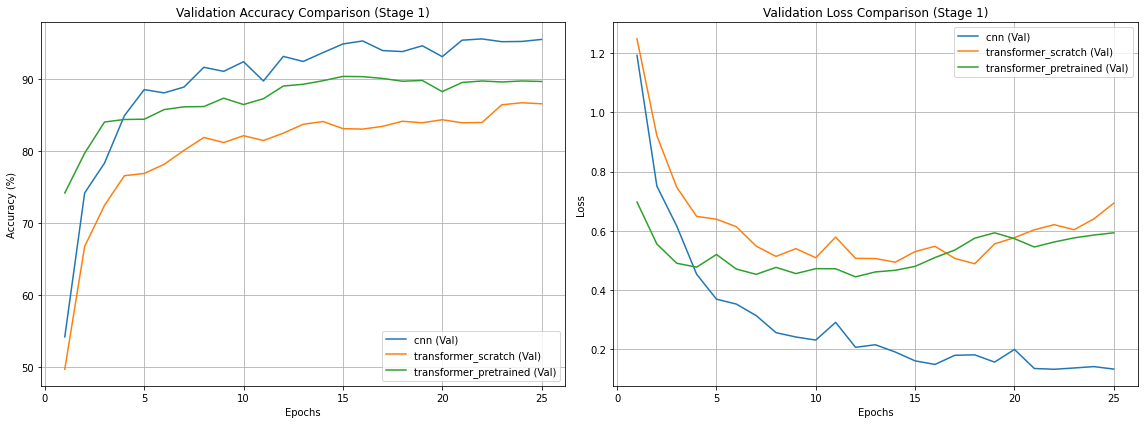

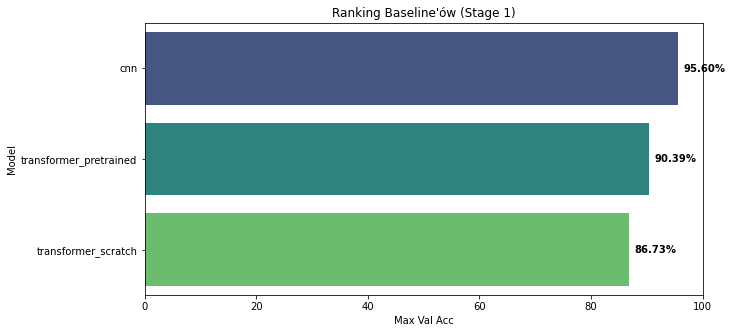


--- TABELA WYNIKÓW STAGE 1 ---
                    Model  Max Val Acc  Max Val F1  Final Loss
0                     cnn    95.601689    0.956152    0.132398
2  transformer_pretrained    90.394089    0.903969    0.593075
1     transformer_scratch    86.734694    0.867670    0.693195


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def analyze_stage_1(results):
    stage_1_keys = [k for k in results.keys() if k.startswith('stage_1')]
    
    plt.figure(figsize=(16, 6))
    
    ax1 = plt.subplot(1, 2, 1)
    ax2 = plt.subplot(1, 2, 2)
    
    comparison_data = []

    for stage_name in stage_1_keys:
        for model_name, data in results[stage_name].items():
            history = data['history']
            epochs = range(1, len(history['val_acc']) + 1)
            
            label = stage_name.replace("stage_1_baseline_", "")
            
            ax1.plot(epochs, history['val_acc'], label=f"{label} (Val)")
            ax2.plot(epochs, history['val_loss'], label=f"{label} (Val)")
            
            comparison_data.append({
                'Model': label,
                'Max Val Acc': max(history['val_acc']),
                'Max Val F1': max(history['val_f1']),
                'Final Loss': history['val_loss'][-1]
            })

    ax1.set_title("Validation Accuracy Comparison (Stage 1)")
    ax1.set_xlabel("Epochs"); ax1.set_ylabel("Accuracy (%)")
    ax1.legend(); ax1.grid(True)

    ax2.set_title("Validation Loss Comparison (Stage 1)")
    ax2.set_xlabel("Epochs"); ax2.set_ylabel("Loss")
    ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.show()

    df_comp = pd.DataFrame(comparison_data).sort_values(by='Max Val Acc', ascending=False)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Max Val Acc', y='Model', data=df_comp, palette='viridis')
    plt.title("Ranking Baseline'ów (Stage 1)")
    plt.xlim(0, 100)
    for i, v in enumerate(df_comp['Max Val Acc']):
        plt.text(v + 1, i, f"{v:.2f}%", color='black', va='center', fontweight='bold')
    plt.show()

    return df_comp

df_stage_1 = analyze_stage_1(results_dict)
print(df_stage_1)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def get_stage_2_df(results):
    rows = []
    stage_2_keys = [k for k in results.keys() if 'stage_2' in k]
    
    for stage in stage_2_keys:
        for model_name, data in results[stage].items():
            conf = data['config']
            hist = data['history']
            
            row = {
                'stage': stage,
                'model_type': conf['model_type'],
                'n_filters': conf['model_params'].get('n_filters'),
                'n_layers': conf['model_params'].get('n_layers'),
                'n_heads': conf['model_params'].get('n_heads'),
                'drop_rate': conf['model_params'].get('drop_rate'),
                'max_val_f1': max(hist['val_f1']) if hist['val_f1'] else 0,
                'max_val_acc': max(hist['val_acc']) if hist['val_acc'] else 0
            }
            rows.append(row)
    
    return pd.DataFrame(rows)

df_s2 = get_stage_2_df(results_dict)

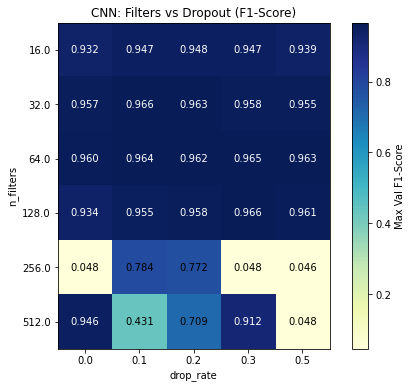

In [ ]:
def plot_manual_heatmap(df, model_type, index_param, col_param, title):
    subset = df[df['model_type'] == model_type]
    pivot = subset.pivot_table(index=index_param, columns=col_param, values='max_val_f1')
    

    data = pivot.values
    y_labels = pivot.index.values
    x_labels = pivot.columns.values

    plt.figure(figsize=(8, 6))
    im = plt.imshow(data, cmap='YlGnBu')
    
    plt.colorbar(im, label='Max Val F1-Score')


    plt.xticks(np.arange(len(x_labels)), x_labels)
    plt.yticks(np.arange(len(y_labels)), y_labels)
    
    plt.xlabel(col_param)
    plt.ylabel(index_param)
    plt.title(title)


    for i in range(len(y_labels)):
        for j in range(len(x_labels)):
            plt.text(j, i, f'{data[i, j]:.3f}', ha="center", va="center", 
                     color="white" if data[i, j] > np.nanmean(data) else "black")

    plt.show()

plot_manual_heatmap(df_s2, 'BaselineCNN', 'n_filters', 'drop_rate', "CNN: Filters vs Dropout (F1-Score)")


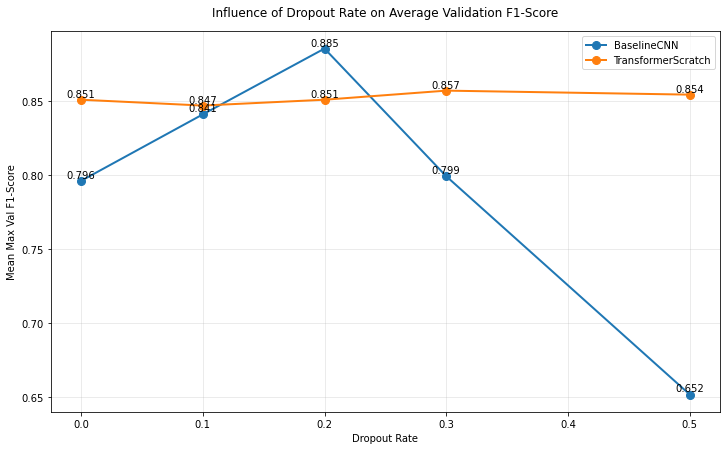

In [ ]:
plt.figure(figsize=(12, 7))


summary_df = df_s2[df_s2['model_type'].isin(['BaselineCNN', 'TransformerScratch'])]
stats = summary_df.groupby(['model_type', 'drop_rate'])['max_val_f1'].mean().unstack(level=0)


for model_name in stats.columns:
    plt.plot(stats.index.values, stats[model_name].values, 
             marker='o', label=model_name, linewidth=2, markersize=8)

plt.title("Influence of Dropout Rate on Average Validation F1-Score", pad=15)
plt.xlabel("Dropout Rate")
plt.ylabel("Mean Max Val F1-Score")
plt.grid(True, alpha=0.3)
plt.legend()

for model_name in stats.columns:
    for x, y in zip(stats.index.values, stats[model_name].values):
        if not np.isnan(y):
            plt.text(x, y + 0.002, f'{y:.3f}', ha='center')

plt.show()

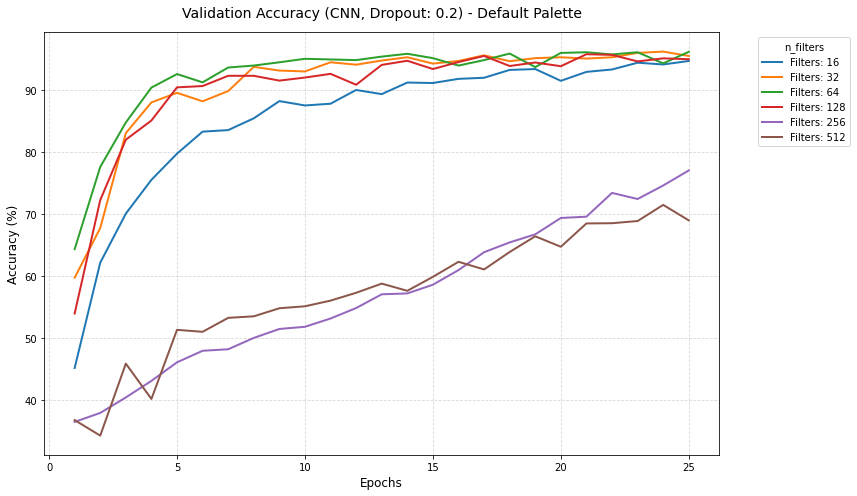

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cnn_accuracy_dropout_02_classic_colors(results):
    stage_key = 'stage_2_cnn_deep_search'
    if stage_key not in results:
        return

    models = results[stage_key]
    collected_plots = []

    for model_name, data in models.items():
        conf = data['config']
        hist = data['history']
        
        if round(conf['model_params'].get('drop_rate', 0), 1) == 0.2:
            n_filters = conf['model_params'].get('n_filters', 0)
            val_acc = hist['val_acc']
            epochs = np.arange(1, len(val_acc) + 1)
            
            collected_plots.append({
                'n_filters': n_filters,
                'epochs': epochs,
                'val_acc': val_acc
            })

    collected_plots.sort(key=lambda x: x['n_filters'])

    if not collected_plots:
        print("⚠️ Nie znaleziono modeli CNN z drop_rate = 0.2")
        return

    plt.figure(figsize=(12, 7))

    for p in collected_plots:
        plt.plot(p['epochs'], p['val_acc'], 
                 label=f"Filters: {p['n_filters']}", 
                 linewidth=2)

    plt.title("Validation Accuracy (CNN, Dropout: 0.2) - Default Palette", fontsize=14, pad=15)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Accuracy (%)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    

    plt.legend(title="n_filters", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_cnn_accuracy_dropout_02_classic_colors(results_dict)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def get_overfitting_analysis(results):
    rows = []
    stage_keys = [k for k in results.keys() if 'stage_2' in k]
    
    for stage in stage_keys:
        for model_name, data in results[stage].items():
            conf = data['config']
            hist = data['history']
            
            acc_history = hist.get('val_acc', [])
            if len(acc_history) < 5: continue
            
            max_acc = max(acc_history)
            last_3_avg = np.mean(acc_history[-3:])
            overfitting_gap = max_acc - last_3_avg
            
            rows.append({
                'model_type': conf['model_type'],
                'n_filters': conf['model_params'].get('n_filters', 0),
                'n_layers': conf['model_params'].get('n_layers', 0),
                'drop_rate': conf['model_params'].get('drop_rate', 0),
                'overfitting_gap': overfitting_gap,
                'max_val_acc': max_acc
            })
            
    return pd.DataFrame(rows)

df_gap = get_overfitting_analysis(results_dict)

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

with open('stage_2_results.json', 'r') as f:
    results = json.load(f)


data = []
for exp_group, models in results.items():

    if "pretrained" in exp_group.lower() or any("pretrained" in k.lower() for k in models.keys()):
        category = "Pretrained Transformer"
    elif "cnn" in exp_group.lower():
        category = "CNN"
    else:
        category = "Transformer Scratch"

    for model_name, details in models.items():
        config = details.get('config', {})
        history = details.get('history', {})
        
        val_acc_list = history.get('val_acc', [])
        train_acc_list = history.get('train_acc', [])
        val_loss_list = history.get('val_loss', [])
        
        if val_acc_list:
            max_val_acc = max(val_acc_list)
            best_epoch = val_acc_list.index(max_val_acc)
            
            data.append({
                'category': category,
                'model_name': model_name,
                'max_val_acc': max_val_acc,
                'best_epoch': best_epoch,
                'val_acc_history': val_acc_list,
                'train_acc_history': train_acc_list,
                'val_loss_history': val_loss_list,
                'best_val_cm': history.get('val_cm', [])[best_epoch] if history.get('val_cm') else None,
                'drop_rate': config.get('model_params', {}).get('drop_rate', None),
            })

df = pd.DataFrame(data)

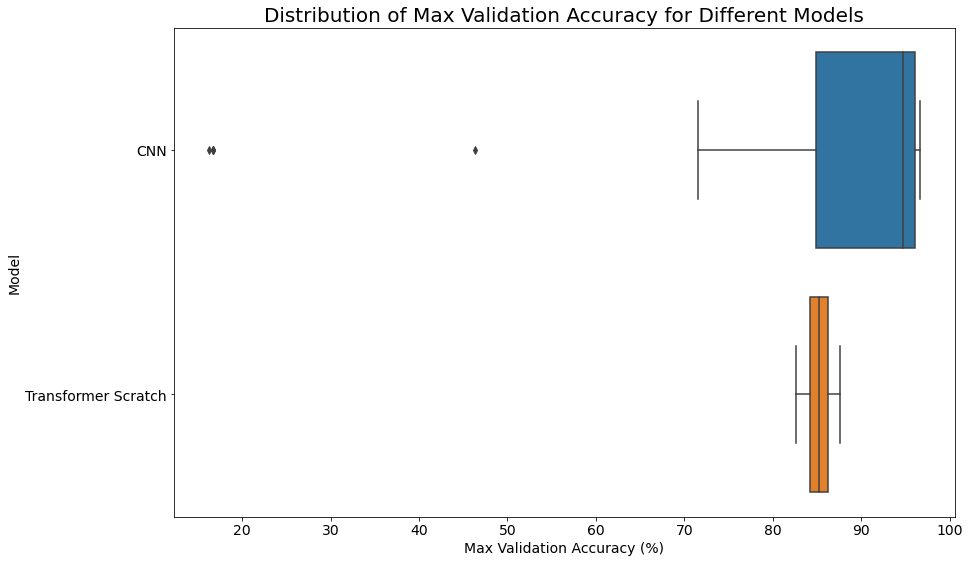

In [15]:
non_pre_data = df.loc[df["category"] != "Pretrained Transformer"]

plt.figure(figsize=(14, 9))
sns.boxplot(x='max_val_acc', y='category', data=non_pre_data)
plt.title('Distribution of Max Validation Accuracy for Different Models', fontsize=20)
plt.xlabel('Max Validation Accuracy (%)', fontsize=14)
plt.ylabel('Model', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.tight_layout()
# plt.savefig('1_distribution.png')
plt.show()

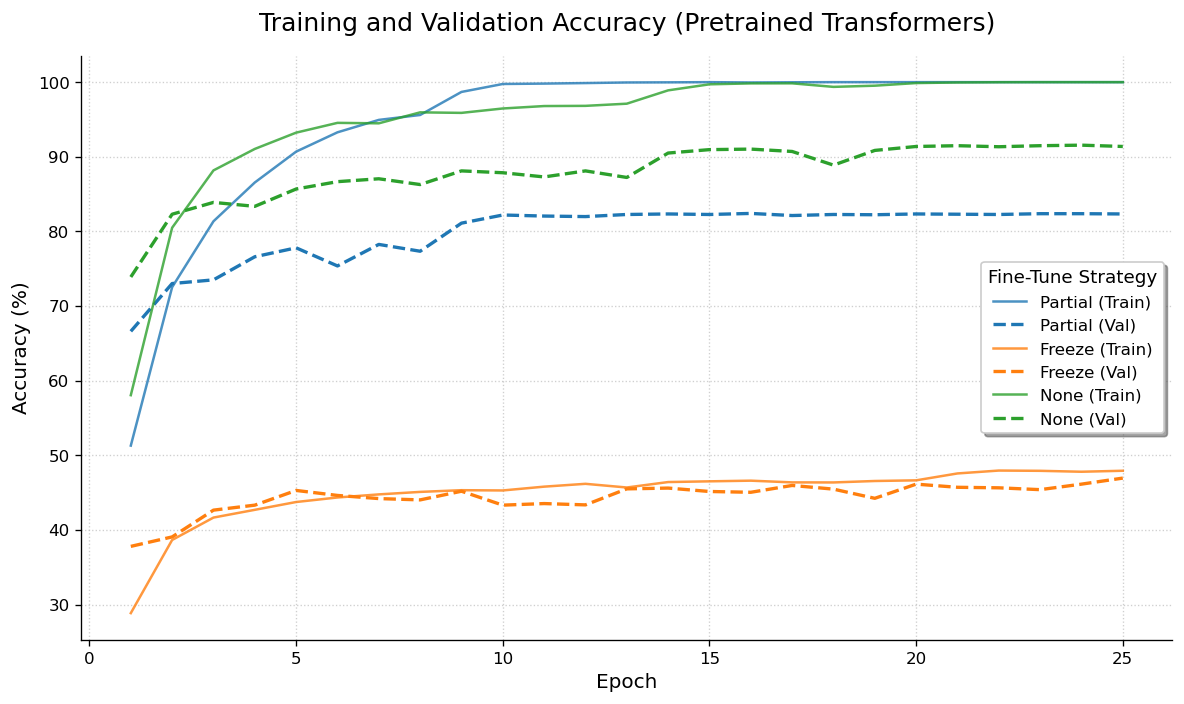

In [ ]:
import json
import matplotlib.pyplot as plt


with open('stage_2_results.json', 'r') as f:
    results = json.load(f)


pretrained_models = {}
for exp_group, models in results.items():
    if "pretrained" in exp_group.lower():
        for m_name, m_data in models.items():
            pretrained_models[m_name] = m_data['history']


if 'pretrained_trans.pth' in pretrained_models:
    del pretrained_models['pretrained_trans.pth']

plt.figure(figsize=(10,6))

for m_name, history in pretrained_models.items():
    if 'train_acc' in history and 'val_acc' in history:
        epochs = range(1, len(history['train_acc']) + 1)
        
        color = next(plt.gca()._get_lines.prop_cycler)['color']
        
        short_name = m_name.replace('pretrained_trans_strategy_', '').replace('.pth', '').replace('_', ' ')
        short_name = short_name.capitalize()
        
        plt.plot(epochs, history['train_acc'], label=f"{short_name} (Train)", 
                 color=color, linestyle='-', alpha=0.8)
        plt.plot(epochs, history['val_acc'], label=f"{short_name} (Val)", 
                 color=color, linestyle='--', linewidth=2)

plt.title('Training and Validation Accuracy (Pretrained Transformers)', fontsize=15, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)

plt.legend(title= "Fine-Tune Strategy", frameon=True, shadow=True, fontsize=10)

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()


plt.show()

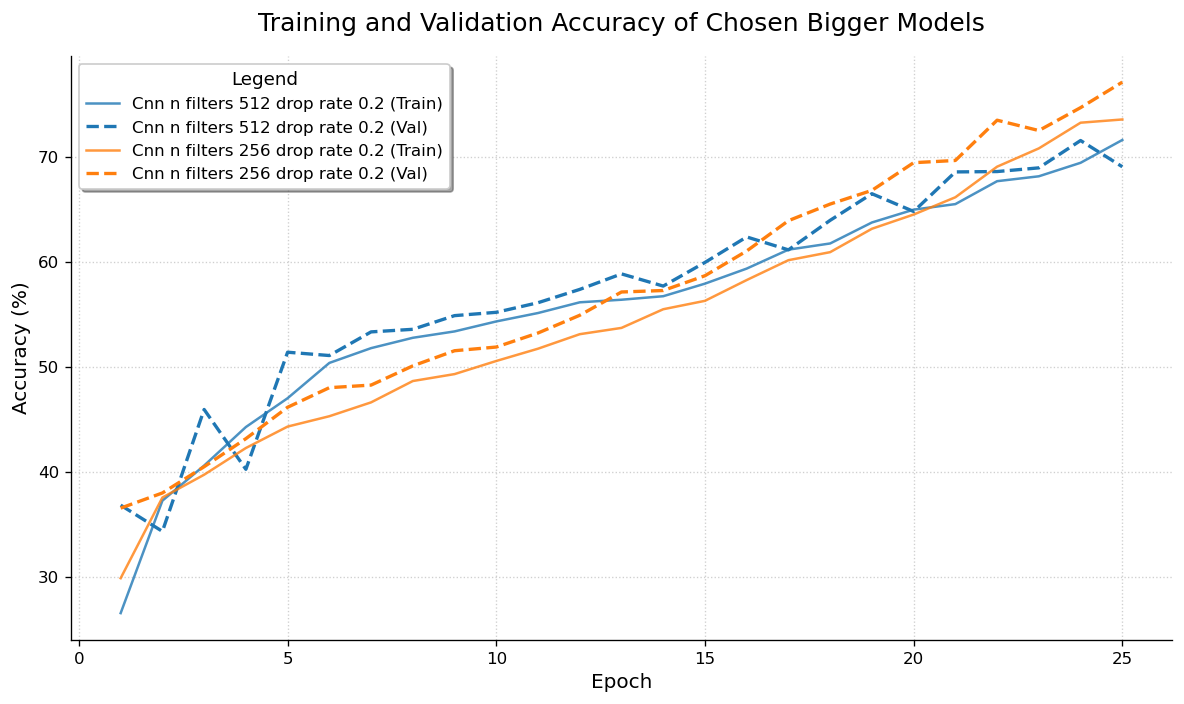

In [ ]:
import json
import matplotlib.pyplot as plt

with open('stage_2_results.json', 'r') as f:
    results = json.load(f)

models_want = [""]
pretrained_models = {}
for exp_group, models in results.items():
    if "stage_2_cnn" in exp_group.lower():
        for m_name, m_data in models.items():
            if ("0.2" in m_name) and ("256" in m_name or "512" in m_name): 
                pretrained_models[m_name] = m_data['history']


if 'pretrained_trans.pth' in pretrained_models:
    del pretrained_models['pretrained_trans.pth']

plt.figure(figsize=(10,6))

for m_name, history in pretrained_models.items():
    if 'train_acc' in history and 'val_acc' in history:
        epochs = range(1, len(history['train_acc']) + 1)
        
        color = next(plt.gca()._get_lines.prop_cycler)['color']
        
        
        short_name = m_name.replace('pretrained_trans_strategy_', '').replace('.pth', '').replace('_', ' ')
        short_name = short_name.capitalize()
        
        plt.plot(epochs, history['train_acc'], label=f"{short_name} (Train)", 
                 color=color, linestyle='-', alpha=0.8)
        plt.plot(epochs, history['val_acc'], label=f"{short_name} (Val)", 
                 color=color, linestyle='--', linewidth=2)

plt.title('Training and Validation Accuracy of Chosen Bigger Models', fontsize=15, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)

plt.legend(title= "Legend", frameon=True, shadow=True, fontsize=10)

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
 
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

with open('stage_2_results.json', 'r') as f:
    data = json.load(f)
 
CLASSES = ["yes", "no", "up", "down", "left", "right"]

def best_f1(run):
    return max(run['history']['val_f1'])
 
def best_acc(run):
    return max(run['history']['val_acc'])
 
def final_lr(run):
    return run['history']['lr'][-1]
 
def overfitting_gap(run):
    h = run['history']
    best_ep = int(np.argmax(h['val_f1']))
    train_acc_at_best = h['train_acc'][best_ep]
    val_acc_at_best   = h['val_acc'][best_ep]
    return train_acc_at_best - val_acc_at_best
 
def convergence_epoch(run, threshold=0.95):
    """First epoch where val_f1 reaches threshold * best_val_f1."""
    f1s = run['history']['val_f1']
    target = threshold * max(f1s)
    for i, v in enumerate(f1s):
        if v >= target:
            return i + 1
    return len(f1s)
 
cnn_rows = []
for name, run in data['stage_2_cnn_deep_search'].items():
    p = run['config']['model_params']
    cnn_rows.append({
        'name': name,
        'n_filters': p['n_filters'],
        'drop_rate': p['drop_rate'],
        'best_f1': best_f1(run),
        'best_acc': best_acc(run),
        'gap': overfitting_gap(run),
        'conv_ep': convergence_epoch(run),
        'history': run['history'],
    })
cnn_rows.sort(key=lambda x: x['best_f1'], reverse=True)
 

tr_rows = []
for name, run in data['stage_2_transformer_deep_search'].items():
    p = run['config']['model_params']
    tr_rows.append({
        'name': name,
        'n_layers': p['n_layers'],
        'n_heads': p['n_heads'],
        'drop_rate': p['drop_rate'],
        'best_f1': best_f1(run),
        'best_acc': best_acc(run),
        'gap': overfitting_gap(run),
        'conv_ep': convergence_epoch(run),
        'history': run['history'],
    })
tr_rows.sort(key=lambda x: x['best_f1'], reverse=True)


pt_rows = []
for name, run in data['stage_2_pretrained_strategy_search'].items():
    p = run['config']['model_params']
    pt_rows.append({
        'name': name,
        'strategy': p['strategy'],
        'best_f1': best_f1(run),
        'best_acc': best_acc(run),
        'history': run['history'],
    })
pt_rows.sort(key=lambda x: x['best_f1'], reverse=True)


FILTERS = [16, 32, 64, 128, 256, 512]
DROP_RATES = [0.0, 0.1, 0.2, 0.3, 0.5]
LAYERS_LIST = [2, 4, 8]
HEADS_LIST  = [4, 8, 16]
 
def cnn_grid(metric='best_f1'):
    grid = np.full((len(FILTERS), len(DROP_RATES)), np.nan)
    for r in cnn_rows:
        i = FILTERS.index(r['n_filters'])
        j = DROP_RATES.index(r['drop_rate'])
        grid[i][j] = r[metric]
    return grid
 
def tr_grid_layers_heads(drop_rate_filter=None, metric='best_f1'):
    grid = np.full((len(LAYERS_LIST), len(HEADS_LIST)), np.nan)
    if drop_rate_filter is not None:
        subset = [r for r in tr_rows if r['drop_rate'] == drop_rate_filter]
    else:
        subset = tr_rows
    for r in subset:
        if r['n_layers'] in LAYERS_LIST and r['n_heads'] in HEADS_LIST:
            i = LAYERS_LIST.index(r['n_layers'])
            j = HEADS_LIST.index(r['n_heads'])
            if np.isnan(grid[i][j]) or r[metric] > grid[i][j]:
                grid[i][j] = r[metric]
    return grid

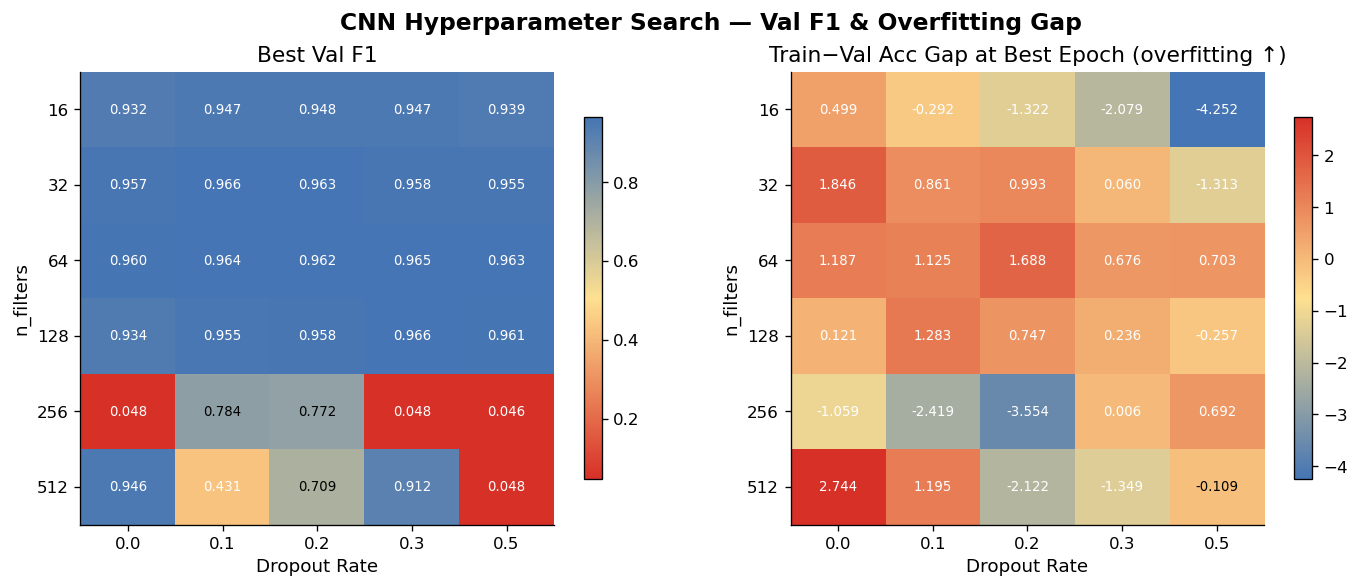

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN Hyperparameter Search — Val F1 & Overfitting Gap', fontsize=14, fontweight='bold')
 
cmap_f1  = LinearSegmentedColormap.from_list('f1', ['#d73027','#fee090','#4575b4'])
cmap_gap = LinearSegmentedColormap.from_list('gap', ['#4575b4','#fee090','#d73027'])
 
for ax, metric, cmap, title in zip(
        axes,
        ['best_f1', 'gap'],
        [cmap_f1, cmap_gap],
        ['Best Val F1', 'Train−Val Acc Gap at Best Epoch (overfitting ↑)']):
    g = cnn_grid(metric)
    im = ax.imshow(g, cmap=cmap, aspect='auto', vmin=np.nanmin(g), vmax=np.nanmax(g))
    ax.set_xticks(range(len(DROP_RATES))); ax.set_xticklabels(DROP_RATES)
    ax.set_yticks(range(len(FILTERS)));   ax.set_yticklabels(FILTERS)
    ax.set_xlabel('Dropout Rate'); ax.set_ylabel('n_filters')
    ax.set_title(title)
    ax.grid(False)
    for i in range(len(FILTERS)):
        for j in range(len(DROP_RATES)):
            if not np.isnan(g[i][j]):
                ax.text(j, i, f'{g[i][j]:.3f}', ha='center', va='center',
                        fontsize=8, color='white' if abs(g[i][j] - np.nanmean(g)) > 0.1 else 'black')
    fig.colorbar(im, ax=ax, shrink=0.8)
 
plt.show()

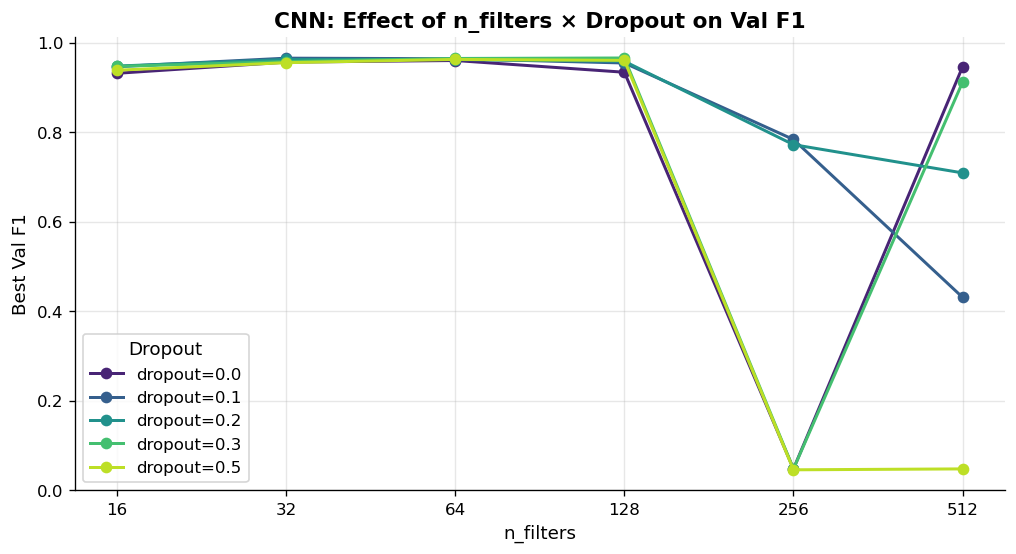

Plot 2 done


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
colors_dr = plt.cm.viridis(np.linspace(0.1, 0.9, len(DROP_RATES)))
for j, dr in enumerate(DROP_RATES):
    f1s = []
    for f in FILTERS:
        match = [r for r in cnn_rows if r['n_filters'] == f and r['drop_rate'] == dr]
        f1s.append(match[0]['best_f1'] if match else np.nan)
    ax.plot(FILTERS, f1s, marker='o', label=f'dropout={dr}', color=colors_dr[j], linewidth=1.8)
 
ax.set_xlabel('n_filters')
ax.set_ylabel('Best Val F1')
ax.set_title('CNN: Effect of n_filters × Dropout on Val F1', fontweight='bold')
ax.set_xscale('log', base=2)
ax.set_xticks(FILTERS); ax.set_xticklabels(FILTERS)
ax.legend(title='Dropout', loc='lower left')
# plt.tight_layout()
plt.show()

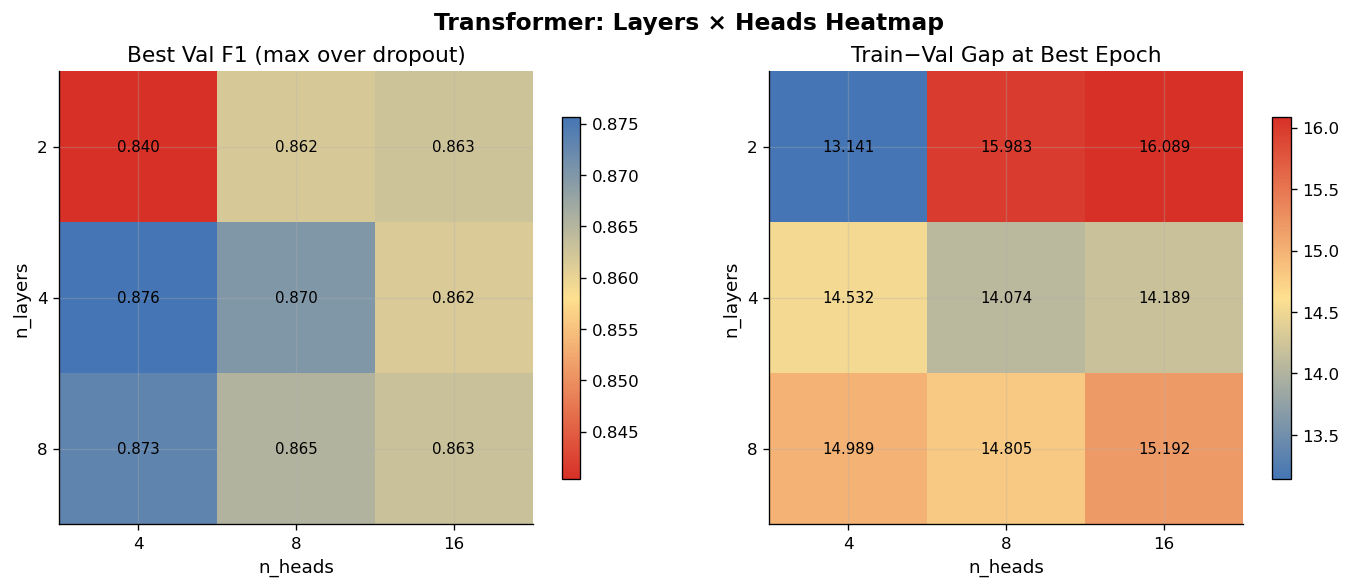

Plot 3 done


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transformer: Layers × Heads Heatmap', fontsize=14, fontweight='bold')
 
g_f1  = tr_grid_layers_heads(metric='best_f1')
g_gap = tr_grid_layers_heads(metric='gap')
 
for ax, g, cmap, title in zip(
        axes,
        [g_f1, g_gap],
        [cmap_f1, cmap_gap],
        ['Best Val F1 (max over dropout)', 'Train−Val Gap at Best Epoch']):
    im = ax.imshow(g, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(HEADS_LIST))); ax.set_xticklabels(HEADS_LIST)
    ax.set_yticks(range(len(LAYERS_LIST))); ax.set_yticklabels(LAYERS_LIST)
    ax.set_xlabel('n_heads'); ax.set_ylabel('n_layers')
    ax.set_title(title)
    for i in range(len(LAYERS_LIST)):
        for j in range(len(HEADS_LIST)):
            if not np.isnan(g[i][j]):
                ax.text(j, i, f'{g[i][j]:.3f}', ha='center', va='center', fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.8)
 
# plt.tight_layout()
plt.show()

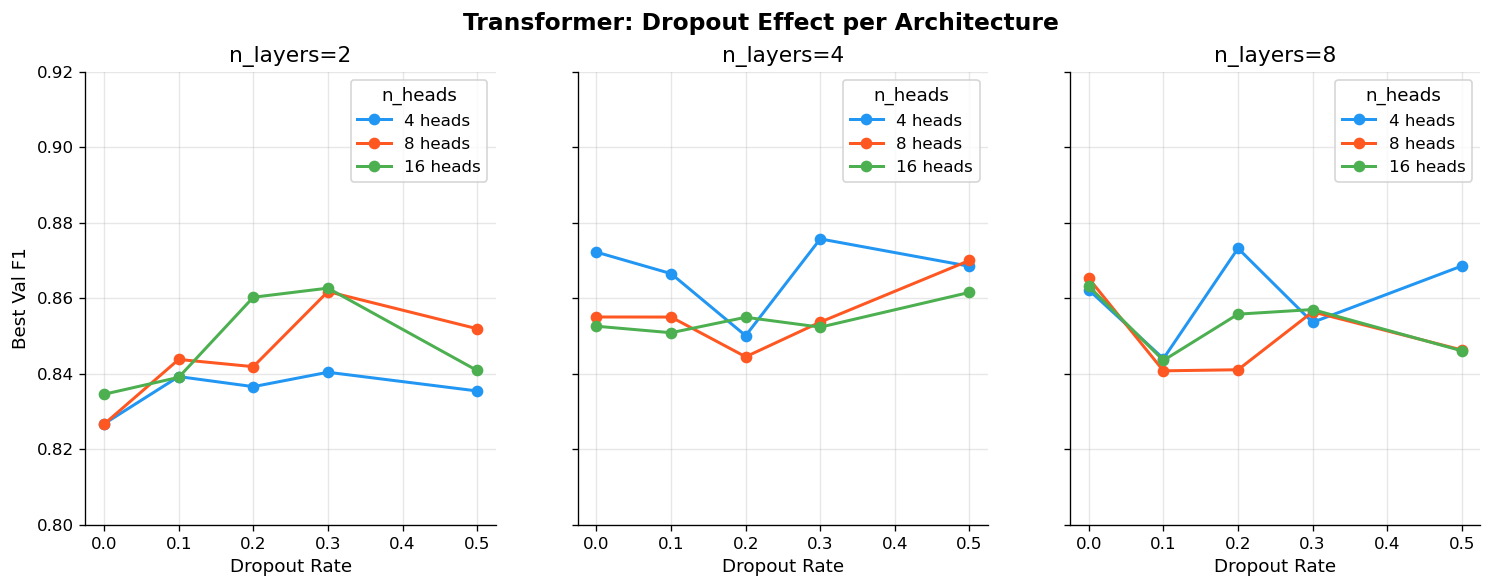

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Transformer: Dropout Effect per Architecture', fontsize=14, fontweight='bold')
 
colors_h = {'4': '#2196F3', '8': '#FF5722', '16': '#4CAF50'}
for ax, nl in zip(axes, LAYERS_LIST):
    for nh in HEADS_LIST:
        subset = sorted([r for r in tr_rows if r['n_layers'] == nl and r['n_heads'] == nh],
                        key=lambda x: x['drop_rate'])
        if not subset: continue
        drs = [r['drop_rate'] for r in subset]
        f1s = [r['best_f1'] for r in subset]
        ax.plot(drs, f1s, marker='o', label=f'{nh} heads', color=colors_h[str(nh)], linewidth=1.8)
    ax.set_title(f'n_layers={nl}')
    ax.set_xlabel('Dropout Rate')
    if nl == LAYERS_LIST[0]: ax.set_ylabel('Best Val F1')
    ax.legend(title='n_heads')
    ax.set_ylim(0.80, 0.92)
 
# plt.tight_layout()
plt.show()

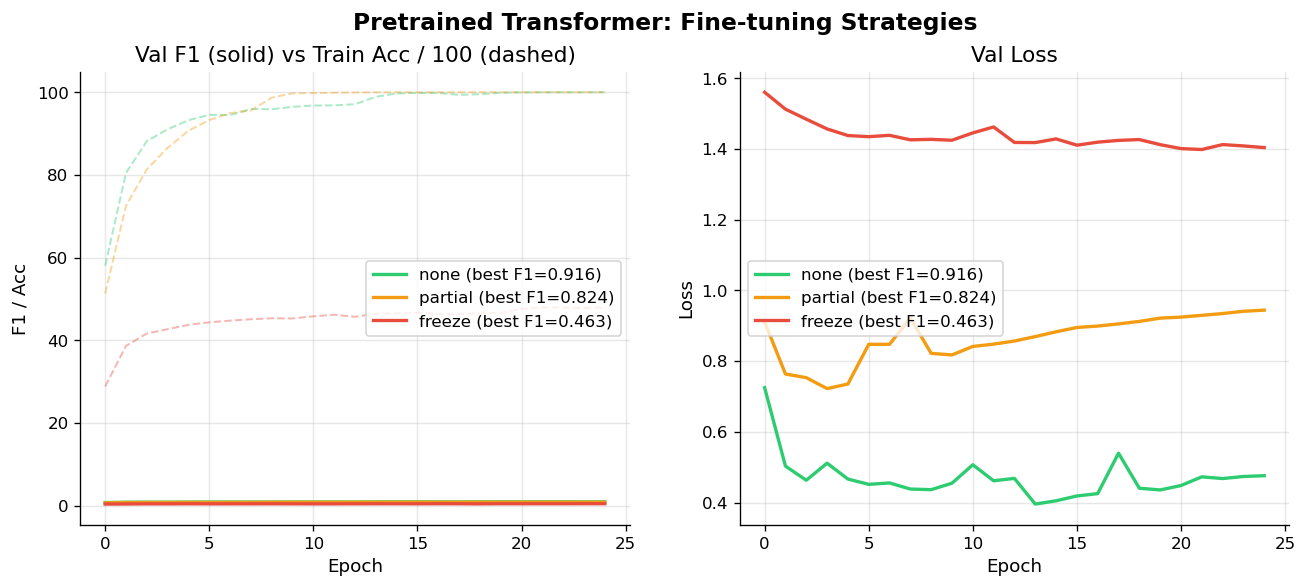

Plot 5 done


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Pretrained Transformer: Fine-tuning Strategies', fontsize=14, fontweight='bold')
colors_strat = {'freeze': '#e74c3c', 'partial': '#f39c12', 'none': '#2ecc71'}
 
for row in pt_rows:
    h = row['history']
    c = colors_strat[row['strategy']]
    label = f"{row['strategy']} (best F1={row['best_f1']:.3f})"
    axes[0].plot(h['val_f1'],  color=c, label=label, linewidth=2)
    axes[1].plot(h['val_loss'], color=c, label=label, linewidth=2)
    axes[0].plot(h['train_acc'], color=c, linestyle='--', alpha=0.4, linewidth=1.2)
 
axes[0].set_title('Val F1 (solid) vs Train Acc / 100 (dashed)'); axes[0].set_ylabel('F1 / Acc')
axes[1].set_title('Val Loss'); axes[1].set_ylabel('Loss')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.legend()
 
# plt.tight_layout()
plt.show()

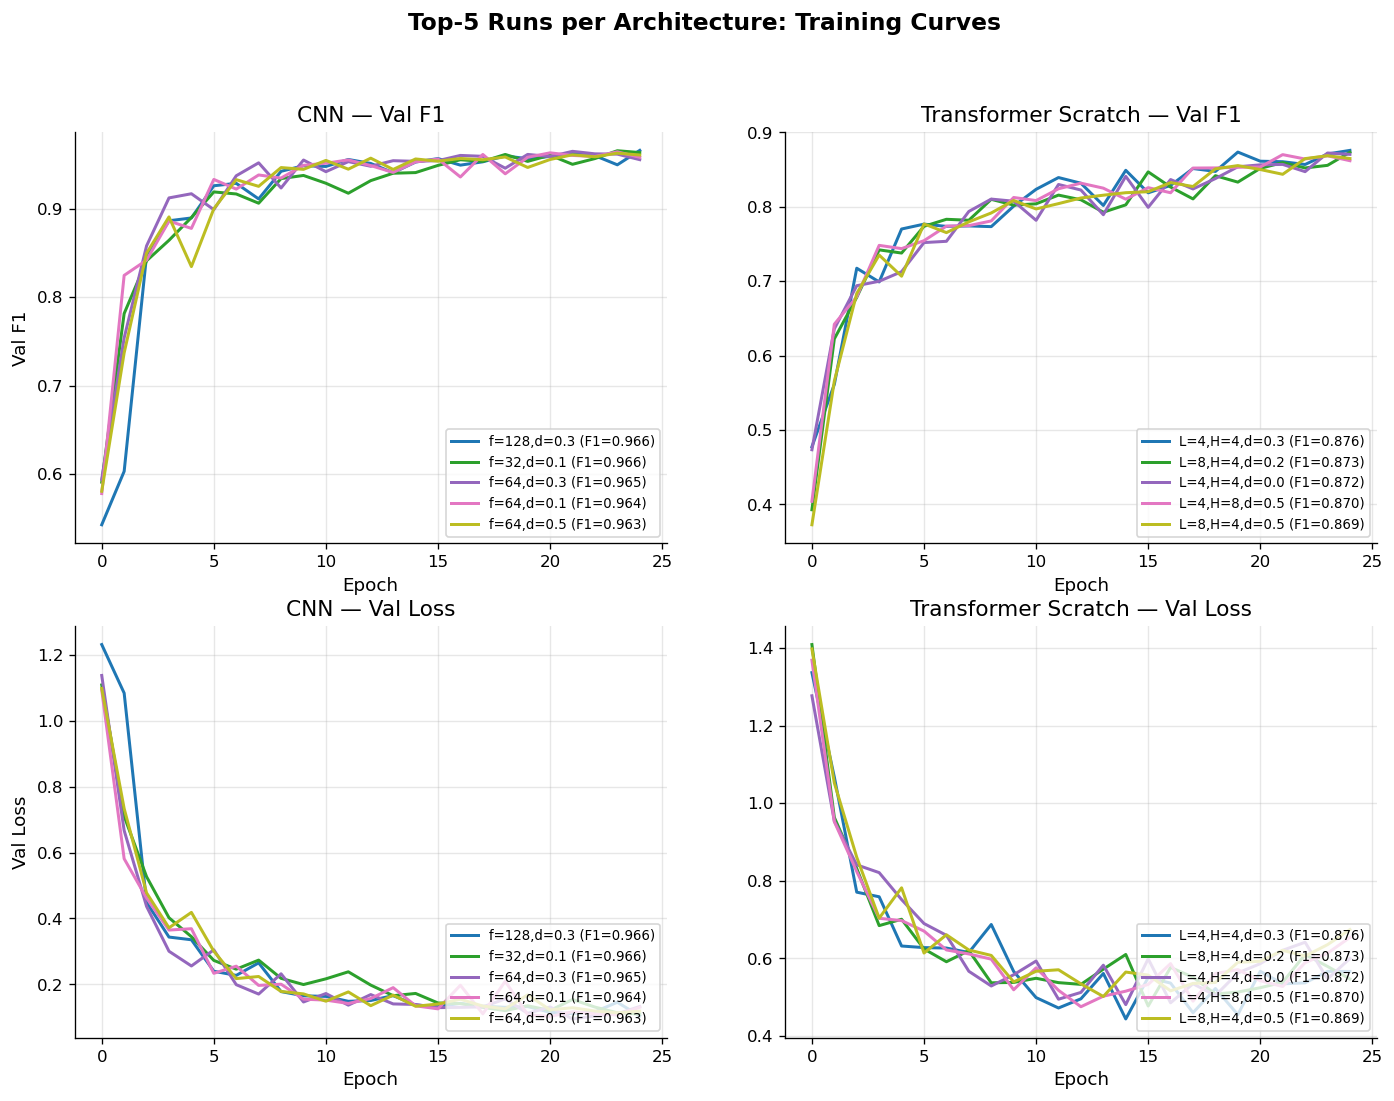

Plot 6 done


In [ ]:
TOP_N = 5
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Top-{TOP_N} Runs per Architecture: Training Curves', fontsize=14, fontweight='bold')
 
cmap_top = plt.cm.tab10
 
def label_cnn(r):
    return f"f={r['n_filters']},d={r['drop_rate']} (F1={r['best_f1']:.3f})"
 
def label_tr(r):
    return f"L={r['n_layers']},H={r['n_heads']},d={r['drop_rate']} (F1={r['best_f1']:.3f})"
 
for col, (rows, label_fn, title) in enumerate([
        (cnn_rows[:TOP_N], label_cnn, 'CNN'),
        (tr_rows[:TOP_N],  label_tr,  'Transformer Scratch')]):
    for i, row in enumerate(rows):
        h = row['history']
        c = cmap_top(i / TOP_N)
        axes[0][col].plot(h['val_f1'],   color=c, label=label_fn(row), linewidth=1.8)
        axes[1][col].plot(h['val_loss'], color=c, label=label_fn(row), linewidth=1.8)
    axes[0][col].set_title(f'{title} — Val F1')
    axes[1][col].set_title(f'{title} — Val Loss')
    for row_ax in axes[:, col]:
        row_ax.set_xlabel('Epoch')
        row_ax.legend(fontsize=8, loc='lower right')
axes[0][0].set_ylabel('Val F1')
axes[1][0].set_ylabel('Val Loss')
 
# plt.tight_layout()
plt.show()

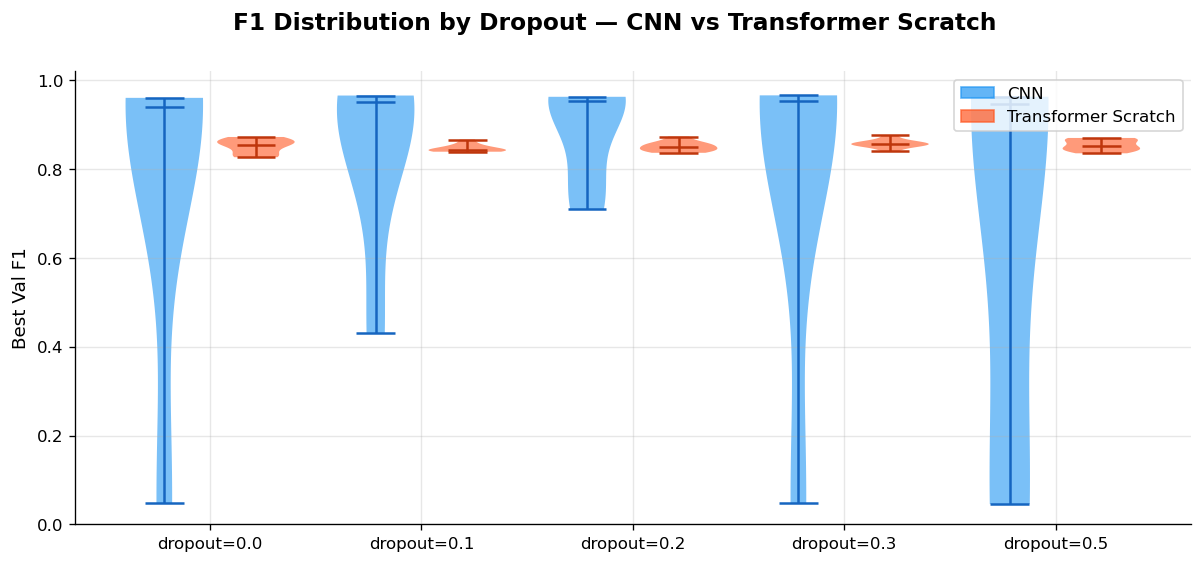

Plot 7 done


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('F1 Distribution by Dropout — CNN vs Transformer Scratch', fontsize=14, fontweight='bold')
 
positions_cnn = np.array([0, 1.5, 3, 4.5, 6])
positions_tr  = positions_cnn + 0.65
tick_positions = (positions_cnn + positions_tr) / 2
 
cnn_by_dr = [[r['best_f1'] for r in cnn_rows if r['drop_rate'] == dr] for dr in DROP_RATES]
tr_by_dr  = [[r['best_f1'] for r in tr_rows  if r['drop_rate'] == dr] for dr in DROP_RATES]
 
parts_cnn = ax.violinplot(cnn_by_dr, positions=positions_cnn, widths=0.55, showmedians=True)
parts_tr  = ax.violinplot(tr_by_dr,  positions=positions_tr,  widths=0.55, showmedians=True)
 
for pc in parts_cnn['bodies']: pc.set_facecolor('#2196F3'); pc.set_alpha(0.6)
for pc in parts_tr['bodies']:  pc.set_facecolor('#FF5722'); pc.set_alpha(0.6)
for key in ['cmedians','cmaxes','cmins','cbars']:
    parts_cnn[key].set_color('#1565C0')
    parts_tr[key].set_color('#BF360C')
 
ax.set_xticks(tick_positions)
ax.set_xticklabels([f'dropout={d}' for d in DROP_RATES])
ax.set_ylabel('Best Val F1')
ax.legend([mpatches.Patch(color='#2196F3', alpha=0.7), mpatches.Patch(color='#FF5722', alpha=0.7)],
          ['CNN', 'Transformer Scratch'])
ax.set_ylim(0, 1.02)
 
# plt.tight_layout()
plt.show()
print('Plot 7 done')

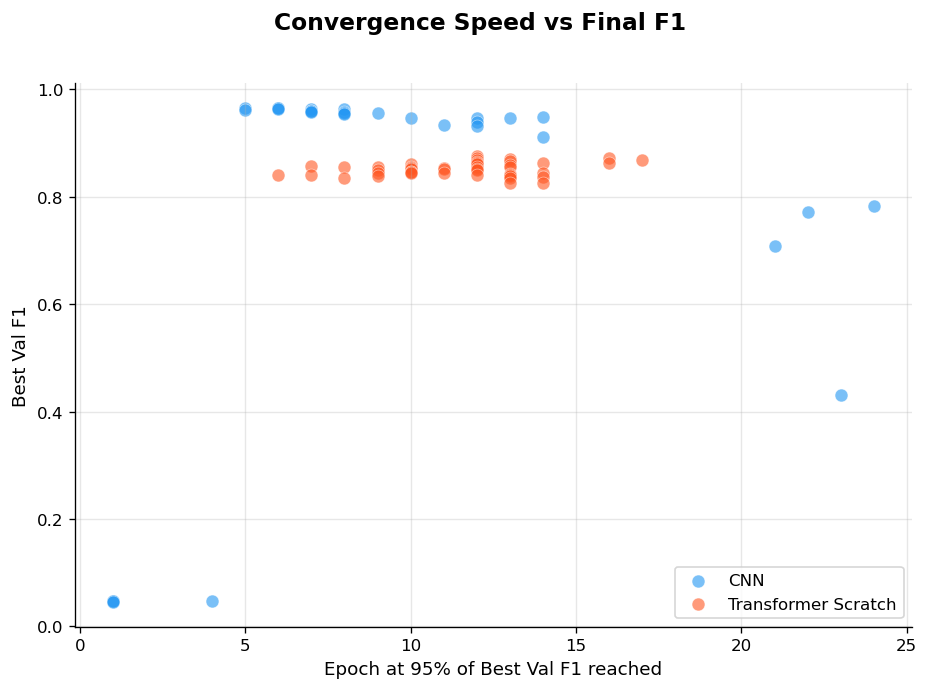

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle('Convergence Speed vs Final F1', fontsize=14, fontweight='bold')
 
for rows, color, label, marker in [
        (cnn_rows, '#2196F3', 'CNN', 'o'),
        (tr_rows,  '#FF5722', 'Transformer Scratch', 'o')]:
    ce = [r['conv_ep'] for r in rows]
    f1 = [r['best_f1'] for r in rows]
    ax.scatter(ce, f1, c=color, alpha=0.6, s=60, label=label, marker=marker, edgecolors='white', linewidth=0.4)
 
ax.set_xlabel('Epoch at 95% of Best Val F1 reached')
ax.set_ylabel('Best Val F1')
ax.legend(loc="lower right")
# ax.axhline(np.mean([r['best_f1'] for r in cnn_rows]), color='#2196F3', linestyle='--', alpha=0.8, linewidth=1, label='CNN mean')
# ax.axhline(np.mean([r['best_f1'] for r in tr_rows]),  color='#FF5722', linestyle='--', alpha=0.8, linewidth=1, label='Transformer Scratch mean')
 
# plt.tight_layout()
plt.show()
# print('Plot 8 done')

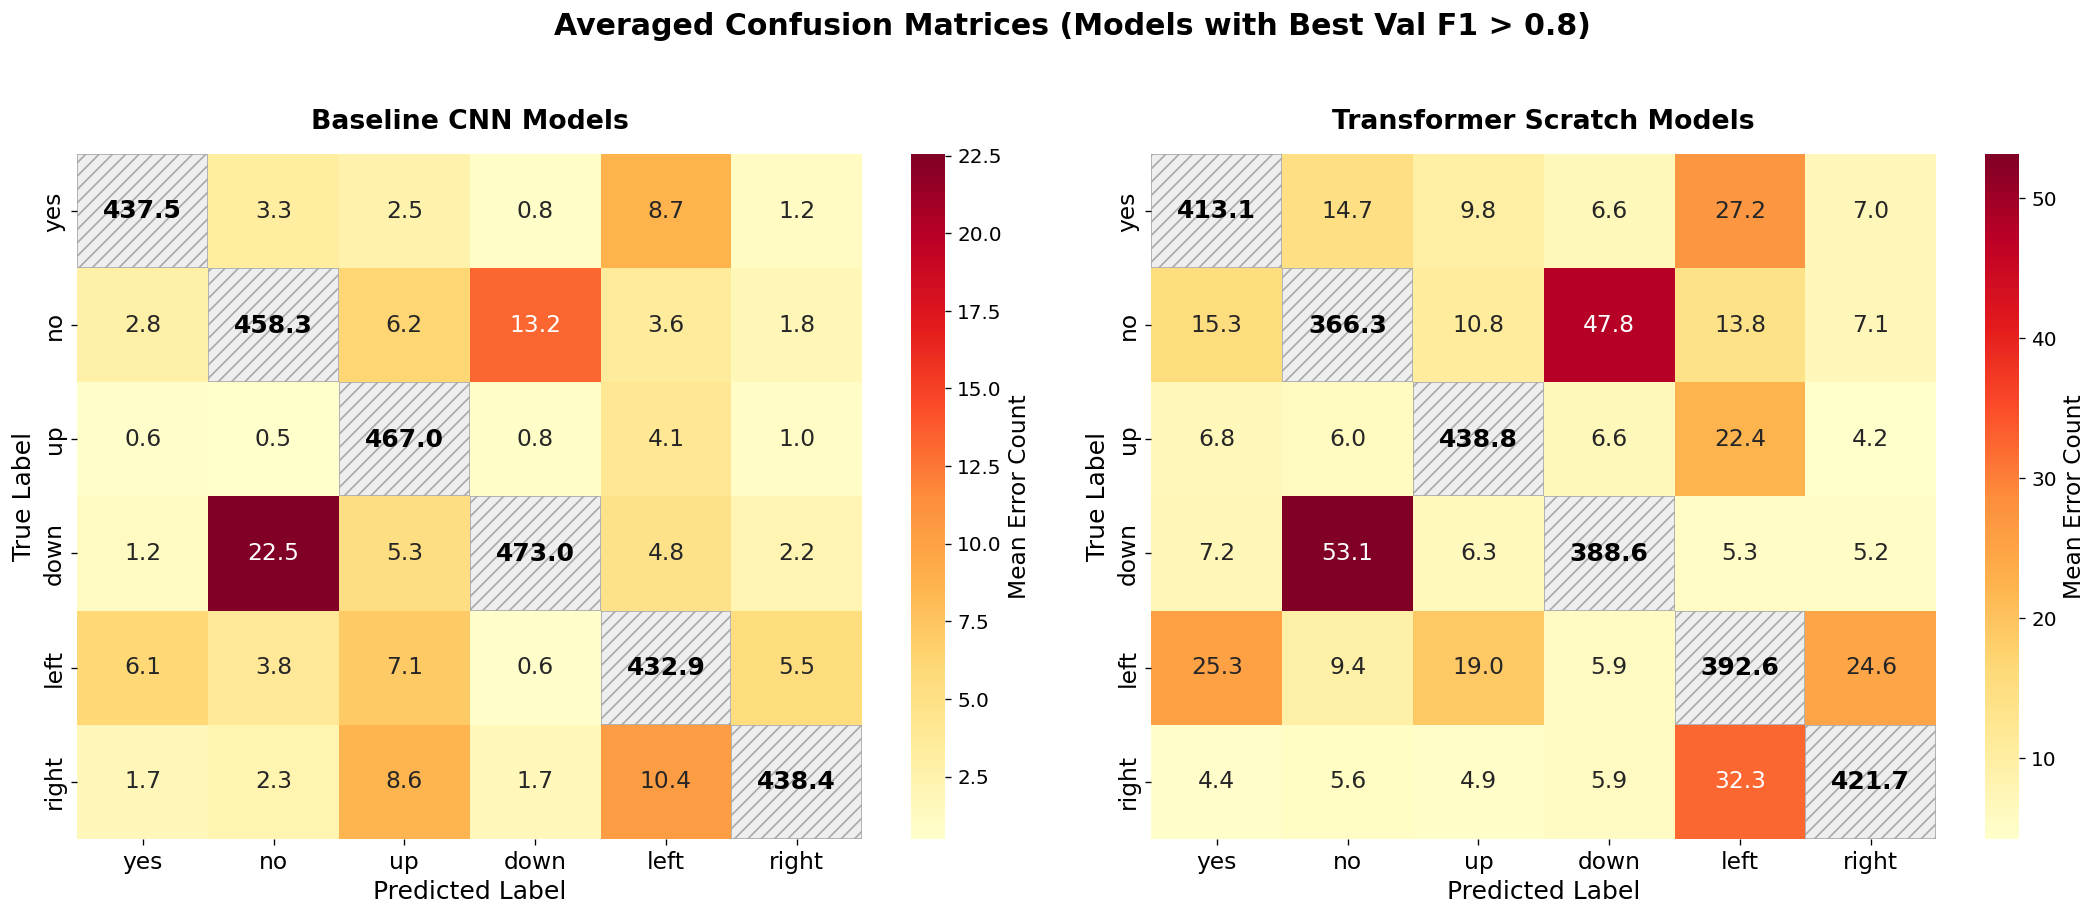

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches

with open('stage_2_results.json', 'r') as f:
    data = json.load(f)

CLASSES = ["yes", "no", "up", "down", "left", "right"]

def get_averaged_cm_above_threshold(models_dict, threshold=0.8):
    selected_cms = []
    for name, run in models_dict.items():
        history = run.get('history', {})
        val_f1 = history.get('val_f1', [])
        val_cm = history.get('val_cm', [])
        if val_f1 and val_cm:
            max_f1 = max(val_f1)
            if max_f1 > threshold:
                best_ep_idx = np.argmax(val_f1)
                selected_cms.append(np.array(val_cm[best_ep_idx]))
    return np.mean(selected_cms, axis=0) if selected_cms else None

cnn_avg_cm = get_averaged_cm_above_threshold(data.get('stage_2_cnn_deep_search', {}))
tr_avg_cm = get_averaged_cm_above_threshold(data.get('stage_2_transformer_deep_search', {}))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Averaged Confusion Matrices (Models with Best Val F1 > 0.8)', fontsize=18, fontweight='bold', y=0.98)

def add_custom_heatmap(ax, cm, title):
    if cm is None:
        ax.text(0.5, 0.5, "No data available", ha='center', va='center', fontsize=16)
        ax.set_title(title)
        return
    
    mask = np.eye(len(CLASSES), dtype=bool)
    

    sns.heatmap(cm, mask=mask, annot=True, fmt='.1f', cmap='YlOrRd', 
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                annot_kws={"size": 14},
                cbar_kws={'label': 'Mean Error Count'})
    

    ax.tick_params(axis='both', which='major', labelsize=14)
    
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label('Mean Error Count', fontsize=14)

    for i in range(len(CLASSES)):
        rect = patches.Rectangle((i, i), 1, 1, fill=True, facecolor='#eeeeee', 
                                 edgecolor='darkgray', hatch='///', zorder=0)
        ax.add_patch(rect)
        
        val = cm[i, i]
        ax.text(i + 0.5, i + 0.5, f'{val:.1f}', 
                ha='center', va='center', color='black', 
                fontweight='bold', fontsize=15) 

    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Predicted Label', fontsize=15)
    ax.set_ylabel('True Label', fontsize=15)

add_custom_heatmap(axes[0], cnn_avg_cm, 'Baseline CNN Models')
add_custom_heatmap(axes[1], tr_avg_cm, 'Transformer Scratch Models')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('combined_avg_cms.png')
plt.show()

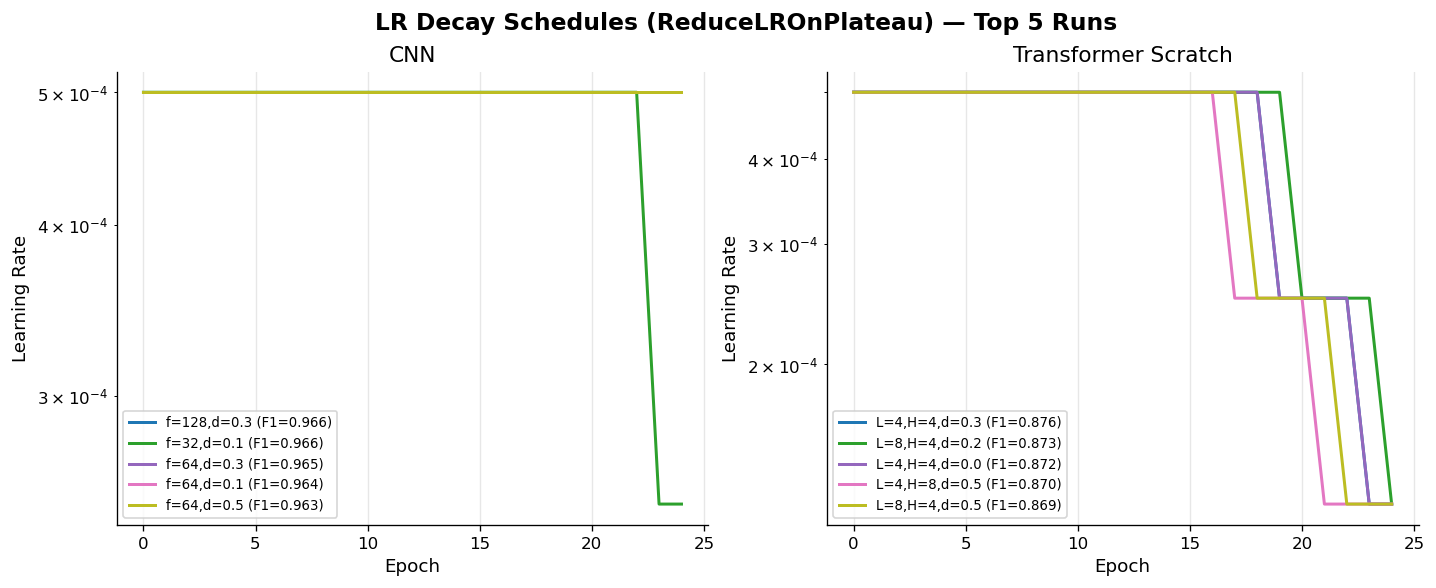

Plot 9 done


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LR Decay Schedules (ReduceLROnPlateau) — Top 5 Runs', fontsize=14, fontweight='bold')
 
for col, (rows, label_fn, title) in enumerate([
        (cnn_rows[:5], label_cnn, 'CNN'),
        (tr_rows[:5],  label_tr,  'Transformer Scratch')]):
    for i, row in enumerate(rows):
        c = cmap_top(i / 5)
        axes[col].plot(row['history']['lr'], color=c, label=label_fn(row), linewidth=1.8)
    axes[col].set_title(title)
    axes[col].set_xlabel('Epoch')
    axes[col].set_ylabel('Learning Rate')
    axes[col].legend(fontsize=8)
    axes[col].set_yscale('log')
 
# plt.tight_layout()
plt.show()
print('Plot 9 done')

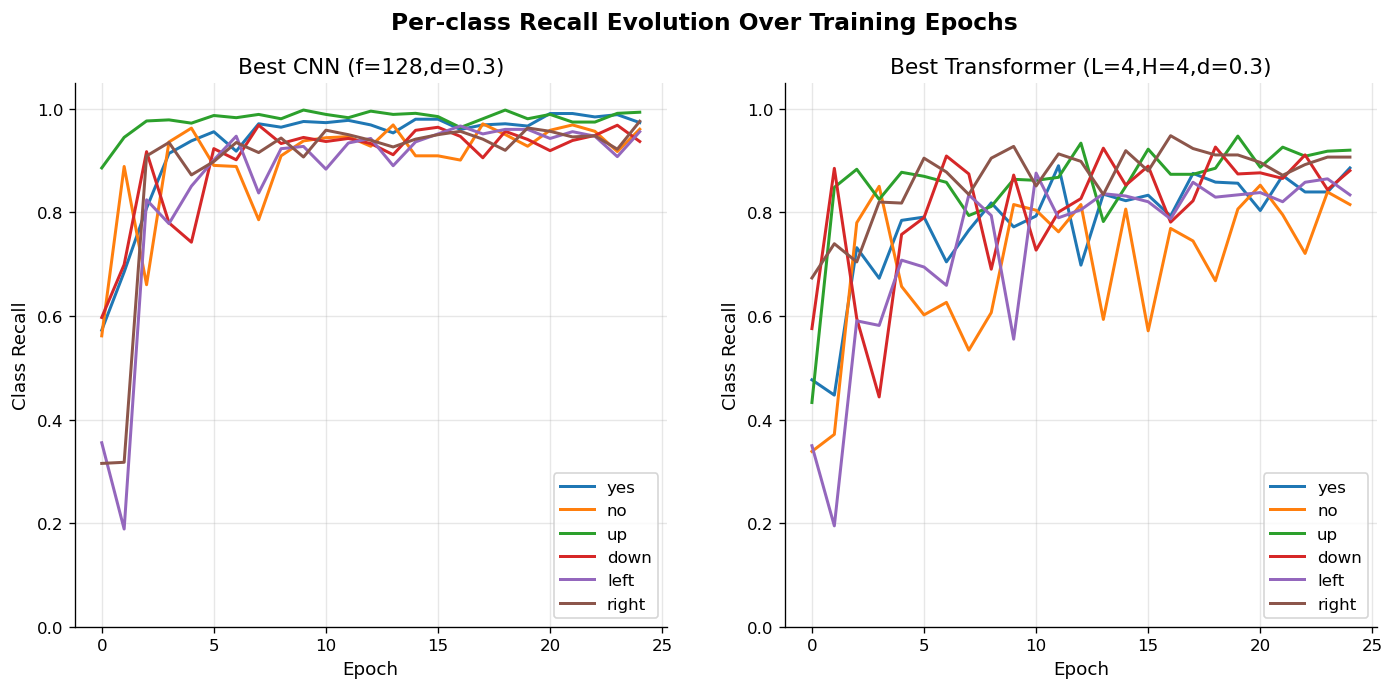

Plot 12 done


In [ ]:
best_cnn = cnn_rows[0]
best_tr  = tr_rows[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Per-class Recall Evolution Over Training Epochs', fontsize=14, fontweight='bold')
class_colors = plt.cm.tab10(np.linspace(0, 0.9, 6))
 
for ax, row, title in zip(axes,
                            [best_cnn, best_tr],
                            [f'Best CNN (f={best_cnn["n_filters"]},d={best_cnn["drop_rate"]})',
                             f'Best Transformer (L={best_tr["n_layers"]},H={best_tr["n_heads"]},d={best_tr["drop_rate"]})']):
    cms = [np.array(cm_ep) for cm_ep in row['history']['val_cm']]
    for cls_idx, cls_name in enumerate(CLASSES):
        recalls = []
        for cm_ep in cms:
            row_sum = cm_ep[cls_idx].sum()
            recalls.append(cm_ep[cls_idx][cls_idx] / row_sum if row_sum > 0 else 0)
        ax.plot(recalls, label=cls_name, 
                # color=class_colors[cls_idx],
                  linewidth=1.8)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Class Recall')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.05)
 
# plt.tight_layout()
plt.show()
print('Plot 12 done')